# Matplotlib & Seaborn — Hands-On Session

**Format:** for each stage, you'll see one short demo, then a **🔧 Try it
yourself** cell to practice the same idea immediately. Everything runs on
one dataset (a fictional coffee shop chain) so the data never changes,
only the chart.

Runs directly in Google Colab — nothing to install, just Runtime → Run all
(or step through cell by cell).

**Pacing guide (~2 hours):**

| Stage | Topic | Minutes |
|---|---|---|
| 1 | Setup & dataset | 5 |
| 2 | Matplotlib basics: core chart types | 20 |
| 3 | Matplotlib: Figure/Axes + customizing | 20 |
| 4 | Saving figures & styles | 5 |
| 5 | Seaborn basics: relational & distribution plots | 25 |
| 6 | Seaborn: categorical plots | 20 |
| 7 | Seaborn: regression & matrix plots | 15 |
| 8 | Combining both + cheat sheet + capstone | 10 |

Cells marked **(optional)** are the first to skip if you're short on time.


## Stage 1 — Setup & Dataset

In [1]:
import numpy as np              # random numbers + array math
import pandas as pd             # DataFrames - the table both libraries plot from
import matplotlib.pyplot as plt # matplotlib
import seaborn as sns           # seaborn (built on matplotlib)

# show plots inline in the notebook:
%matplotlib inline
np.random.seed(42)               # same "random" numbers every run


In [2]:
# One dataset for the whole notebook: daily sales for a coffee shop chain
dates = pd.date_range("2024-01-01", "2024-12-31", freq="D")   # every day in 2024
cities = ["Boston", "Austin", "Seattle", "Denver"]
categories = ["Coffee", "Tea", "Smoothie", "Pastry"]
price = {"Coffee": 4.5, "Tea": 3.5, "Smoothie": 5.5, "Pastry": 3.0}

rows = []
for d in dates:
    month = d.month
    seasonal_temp = 50 + 30 * np.sin((month - 1) / 12 * 2 * np.pi - np.pi / 2)  # warm in summer, cold in winter
    for city in cities:
        city_offset = {"Boston": -5, "Austin": 15, "Seattle": -8, "Denver": 2}[city]
        temp = seasonal_temp + city_offset + np.random.normal(0, 4)             # this city's temp today
        for cat in categories:
            base = {"Coffee": 220, "Tea": 90, "Smoothie": 60, "Pastry": 130}[cat]
            temp_effect = 0
            if cat == "Smoothie":
                temp_effect = (temp - 60) * 1.8      # smoothies sell more when hot
            elif cat == "Coffee":
                temp_effect = (60 - temp) * 0.9      # coffee sells more when cold
            sales = max(0, base + temp_effect + np.random.normal(0, 18))
            rating = np.clip(np.random.normal(4.2, 0.4), 1, 5)
            num_customers = max(0, sales / price[cat] + np.random.normal(0, 4))
            rows.append([d, city, cat, round(temp, 1), round(sales, 2), round(rating, 2), round(num_customers)])

df = pd.DataFrame(rows, columns=["date", "city", "category", "avg_temp", "daily_sales", "rating", "num_customers"])
df["month"] = df["date"].dt.month_name().str[:3]        # "Jan", "Feb", ...
df["day_of_week"] = df["date"].dt.day_name()             # "Monday", "Tuesday", ...
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

print(df.shape)
df.head()


(5856, 10)


,date,city,category,avg_temp,daily_sales,rating,num_customers,month,day_of_week,is_weekend
0,2024-01-01,Boston,Coffee,17.0,256.22,4.46,63,Jan,Monday,False
1,2024-01-01,Boston,Tea,17.0,85.79,4.11,31,Jan,Monday,False
2,2024-01-01,Boston,Smoothie,17.0,0.00,4.01,2,Jan,Monday,False
3,2024-01-01,Boston,Pastry,17.0,121.66,4.01,42,Jan,Monday,False
4,2024-01-01,Austin,Coffee,27.3,218.34,3.98,44,Jan,Monday,False


## Stage 2 — Matplotlib Basics: Core Chart Types (~20 min)

Five chart types, five purposes. Same dataset, different question each time.


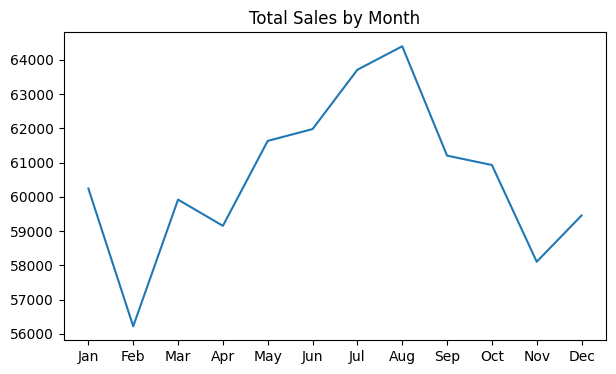

In [3]:
# LINE - a value over an ordered sequence (time)
monthly_total = df.groupby("month", sort=False)["daily_sales"].sum().reindex(month_order)  # total $ per month, Jan->Dec

plt.figure(figsize=(7, 4))              # new figure, 7in x 4in
plt.plot(monthly_total.index, monthly_total.values)   # x = months, y = totals
plt.title("Total Sales by Month")
plt.show()


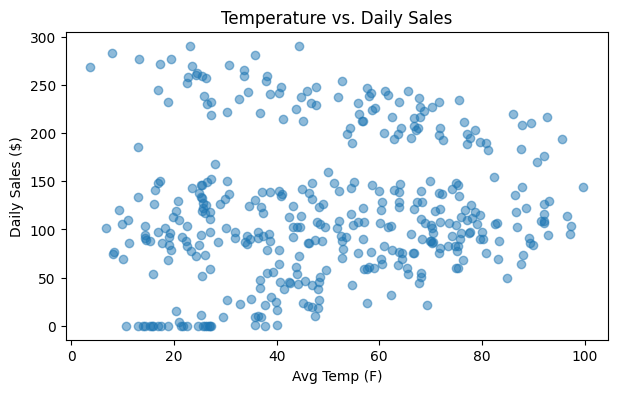

In [4]:
# SCATTER - relationship between two numbers
sample = df.sample(400, random_state=1)   # 400 random rows, so points aren't overcrowded

plt.figure(figsize=(7, 4))
plt.scatter(sample["avg_temp"], sample["daily_sales"], alpha=0.5)  # alpha = transparency
plt.title("Temperature vs. Daily Sales")
plt.xlabel("Avg Temp (F)")
plt.ylabel("Daily Sales ($)")
plt.show()


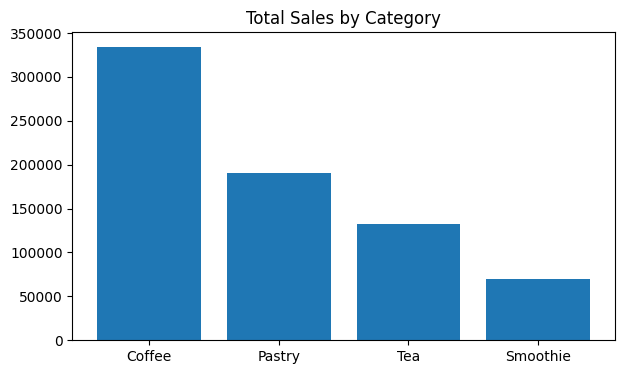

In [5]:
# BAR - compare totals across categories
totals_by_category = df.groupby("category")["daily_sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(totals_by_category.index, totals_by_category.values)
plt.title("Total Sales by Category")
plt.show()


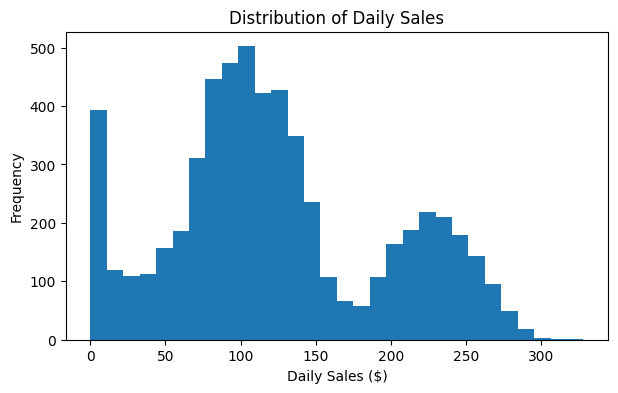

In [6]:
# HISTOGRAM - the spread/shape of one number
plt.figure(figsize=(7, 4))
plt.hist(df["daily_sales"], bins=30)   # 30 buckets across the range of daily_sales
plt.title("Distribution of Daily Sales")
plt.xlabel("Daily Sales ($)")
plt.ylabel("Frequency")
plt.show()


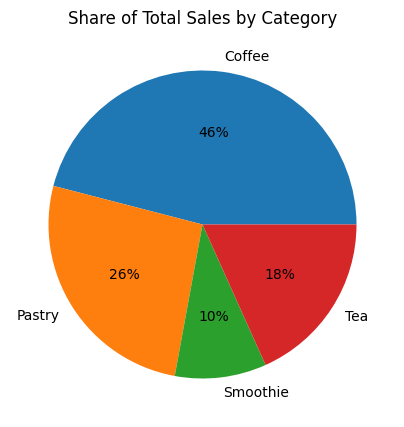

In [7]:
# PIE - share of a whole (use only for a handful of slices)
share_by_category = df.groupby("category")["daily_sales"].sum()

plt.figure(figsize=(5, 5))
plt.pie(share_by_category.values, labels=share_by_category.index, autopct="%1.0f%%")  # autopct prints % on each slice
plt.title("Share of Total Sales by Category")
plt.show()


### 🔧 Try it yourself

In [8]:
# 1. Line chart: total sales by month, but for Boston only
#    hint: filter df to city == "Boston" before grouping by month
# ...

# 2. Bar chart: total sales by CITY instead of by category
# ...

# 3. Histogram: distribution of "rating" instead of "daily_sales"
# ...


**✅ Checkpoint** — everyone should now have 5 chart types working before moving on.

## Stage 3 — Figure/Axes & Customizing Plots (~20 min)

`fig, ax = plt.subplots()` gives you both the canvas (`fig`) and the plot
area (`ax`) as named objects — needed the moment you have more than one
chart per figure.


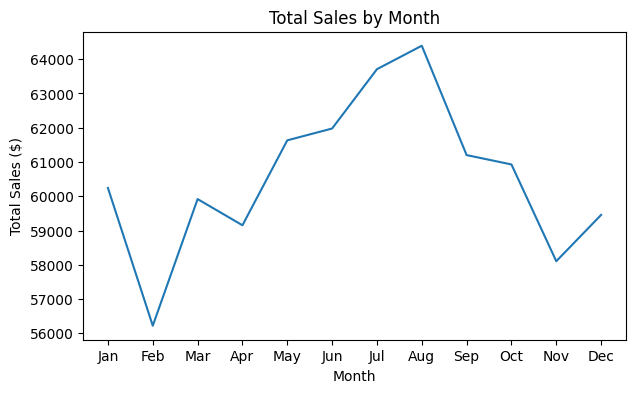

In [9]:
# fig, ax INSTEAD OF plain plt - same chart, object-oriented style
fig, ax = plt.subplots(figsize=(7, 4))     # one Figure + one Axes together

ax.plot(monthly_total.index, monthly_total.values)
ax.set_title("Total Sales by Month")       # ax.set_title, not plt.title
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")
plt.show()


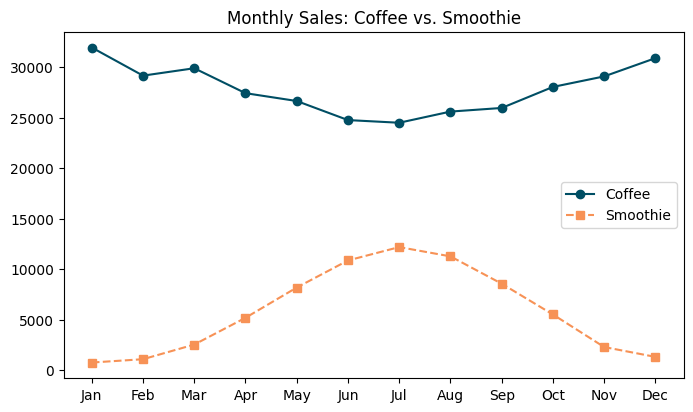

In [10]:
# LABELS + LEGEND + COLORS/STYLES/MARKERS, together
coffee_trend = df[df.category == "Coffee"].groupby("month", sort=False)["daily_sales"].sum().reindex(month_order)
smoothie_trend = df[df.category == "Smoothie"].groupby("month", sort=False)["daily_sales"].sum().reindex(month_order)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(coffee_trend.index, coffee_trend.values,
        color="#004E64", linestyle="-", marker="o", label="Coffee")    # label -> shows up in legend
ax.plot(smoothie_trend.index, smoothie_trend.values,
        color="#F79256", linestyle="--", marker="s", label="Smoothie")

ax.set_title("Monthly Sales: Coffee vs. Smoothie")
ax.legend()                                 # draws the legend using each label=
plt.show()


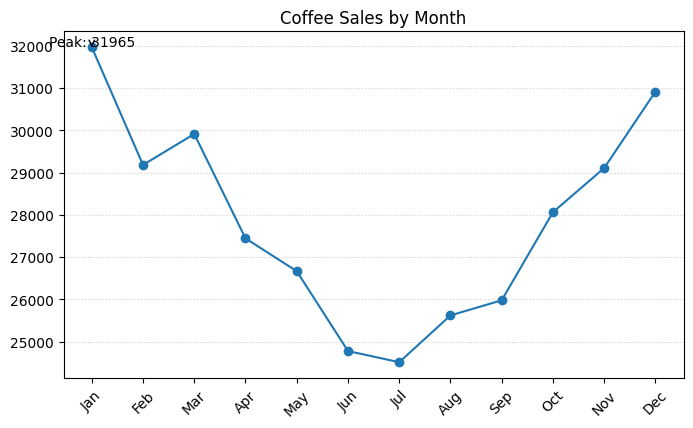

In [11]:
# TICKS, GRIDLINES & ANNOTATION
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(coffee_trend.index, coffee_trend.values, marker="o")

ax.tick_params(axis="x", rotation=45)                  # rotate x labels so months don't overlap
ax.grid(True, axis="y", linestyle=":", alpha=0.6)      # dotted horizontal gridlines only

peak_month, peak_value = coffee_trend.idxmax(), coffee_trend.max()
ax.annotate(f"Peak: {peak_value:.0f}",
            xy=(peak_month, peak_value),                # point the arrow AT
            xytext=(peak_month, peak_value + 30),        # put the TEXT here
            arrowprops=dict(arrowstyle="->"), ha="center")

ax.set_title("Coffee Sales by Month")
plt.show()


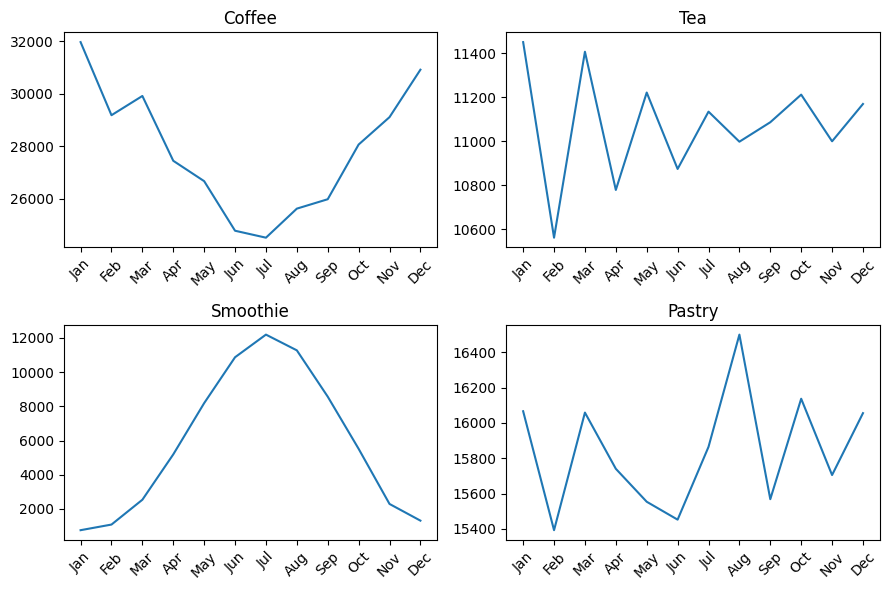

In [12]:
# MULTIPLE SUBPLOTS: one mini-chart per category, in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(9, 6))    # axes is a 2x2 array of Axes objects

for ax, cat in zip(axes.flat, categories):         # .flat loops through all 4, regardless of shape
    trend = df[df.category == cat].groupby("month", sort=False)["daily_sales"].sum().reindex(month_order)
    ax.plot(trend.index, trend.values)
    ax.set_title(cat)
    ax.tick_params(axis="x", rotation=45)

fig.tight_layout()      # auto-adds spacing so titles/labels don't overlap
plt.show()


### (optional) Twin Axes — two different y-scales, one chart

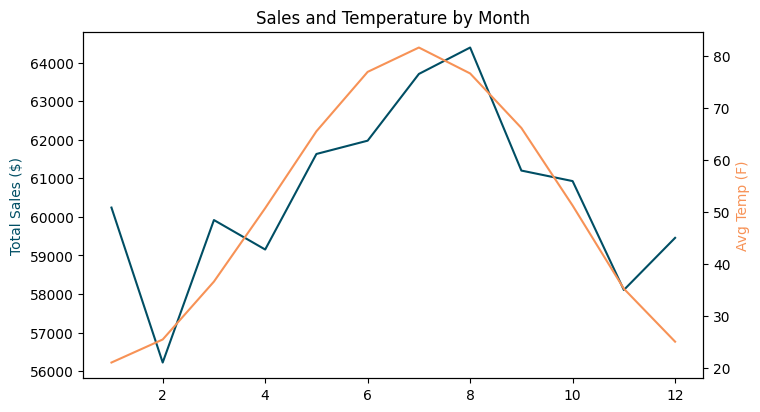

In [13]:
daily_avg_month = (
    df.groupby(df["date"].dt.month)
      .agg(daily_sales=("daily_sales", "sum"), avg_temp=("avg_temp", "mean"))
)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(daily_avg_month.index, daily_avg_month["daily_sales"], color="#004E64", label="Sales ($)")
ax1.set_ylabel("Total Sales ($)", color="#004E64")

ax2 = ax1.twinx()    # a second Axes sharing the same x-axis, with its OWN y-axis
ax2.plot(daily_avg_month.index, daily_avg_month["avg_temp"], color="#F79256", label="Avg Temp (F)")
ax2.set_ylabel("Avg Temp (F)", color="#F79256")

ax1.set_title("Sales and Temperature by Month")
plt.show()


### 🔧 Try it yourself

In [14]:
# 1. Rebuild the Coffee vs. Smoothie line chart, but use Tea vs. Pastry instead
# ...

# 2. Add gridlines and an annotation marking the LOWEST month, not the peak
#    hint: idxmin() / min() instead of idxmax() / max()
# ...

# 3. Build a 1x2 (not 2x2) subplot grid comparing just Coffee and Tea
# ...


**✅ Checkpoint** — everyone can build a labeled, styled, multi-subplot matplotlib chart.

## Stage 4 — Saving Figures & Built-in Styles (~5 min)

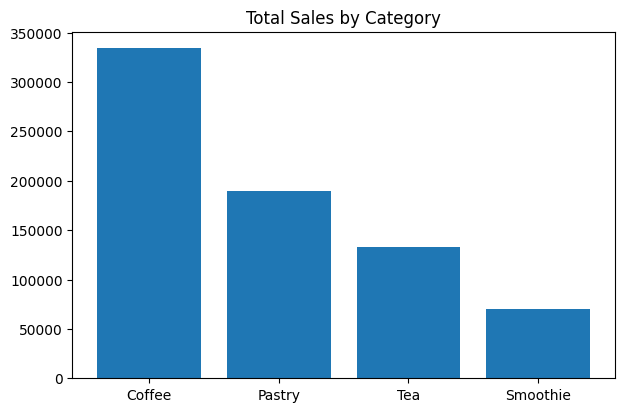

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(totals_by_category.index, totals_by_category.values)
ax.set_title("Total Sales by Category")

fig.savefig("total_sales_by_category.png", dpi=150, bbox_inches="tight")  # save BEFORE show()
plt.show()


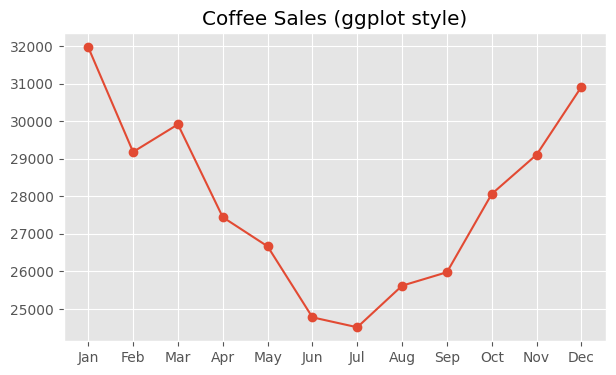

In [16]:
with plt.style.context("ggplot"):     # applies ONLY inside this block, doesn't affect later cells
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(coffee_trend.index, coffee_trend.values, marker="o")
    ax.set_title("Coffee Sales (ggplot style)")
    plt.show()


## Stage 5 — Seaborn: Relational & Distribution Plots (~25 min)

Seaborn is built on matplotlib. It adds nicer defaults, works straight from
a DataFrame (`data=df, x=..., y=..., hue=...`), and ships ready-made
statistical charts.

**One key idea:** most seaborn functions come in two flavors —
**axes-level** (`sns.scatterplot`, takes `ax=` and fits into your own grid)
and **figure-level** (`sns.relplot`, manages its own figure and can facet
with `col=`/`row=`).


In [17]:
sns.set_theme(style="whitegrid")   # switch matplotlib's defaults to seaborn's, for every plot from now on


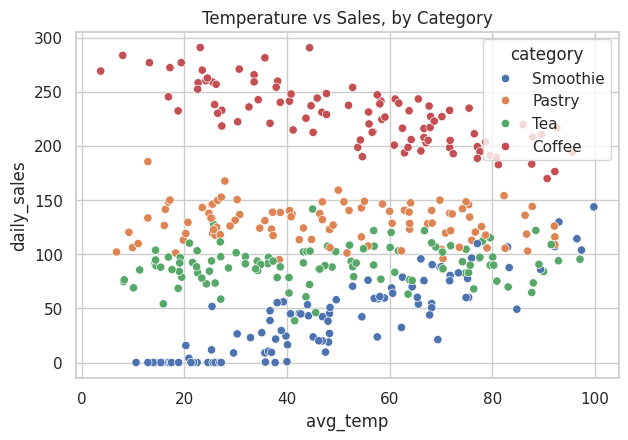

In [18]:
# AXES-LEVEL: sns.scatterplot draws onto an Axes we control
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(data=sample, x="avg_temp", y="daily_sales", hue="category", ax=ax)  # hue -> color by category
ax.set_title("Temperature vs Sales, by Category")
plt.show()


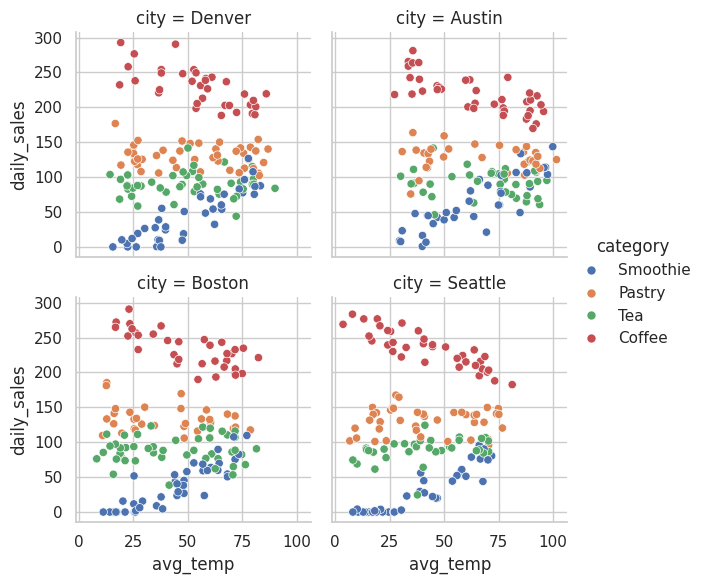

In [19]:
# FIGURE-LEVEL: sns.relplot manages its own figure AND facets automatically
sns.relplot(
    data=df.sample(600, random_state=1),
    x="avg_temp", y="daily_sales",
    hue="category",   # color by category
    col="city",        # one small chart PER CITY
    col_wrap=2, height=3,
)
plt.show()


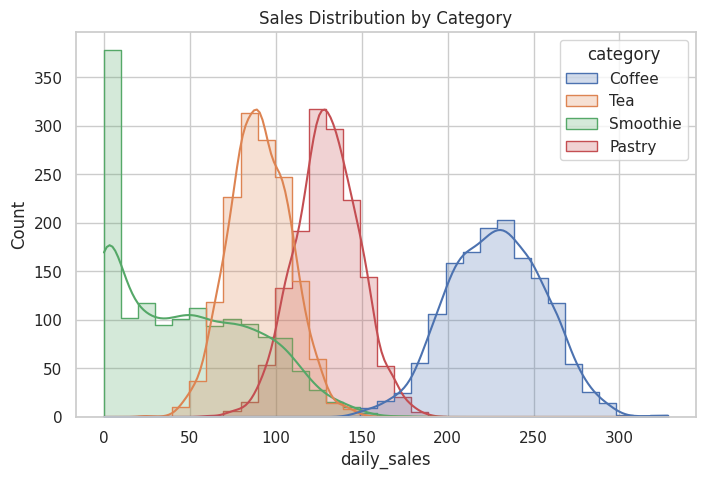

In [20]:
# DISTRIBUTION: histplot (histogram + optional smoothed curve)
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x="daily_sales", hue="category", kde=True, element="step", ax=ax)  # kde=True adds the curve
ax.set_title("Sales Distribution by Category")
plt.show()


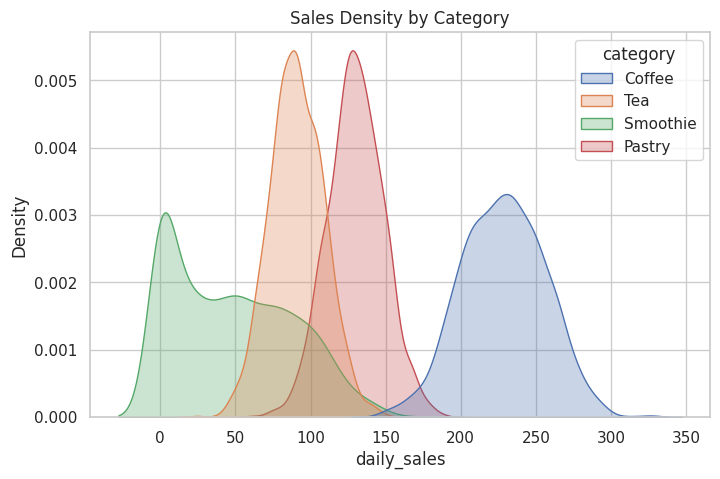

In [21]:
# DISTRIBUTION: kdeplot (just the smoothed curve - cleaner with many groups)
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=df, x="daily_sales", hue="category", fill=True, alpha=0.3, ax=ax)
ax.set_title("Sales Density by Category")
plt.show()


### (optional) rugplot, ecdfplot & displot

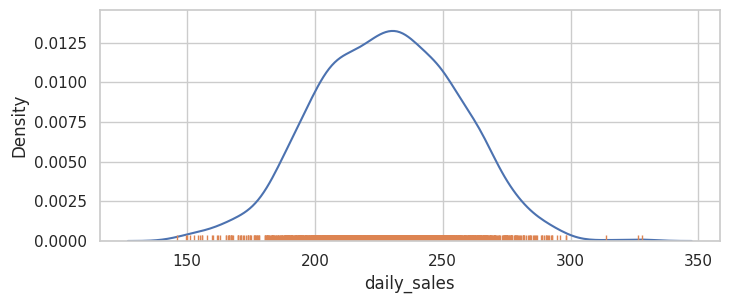

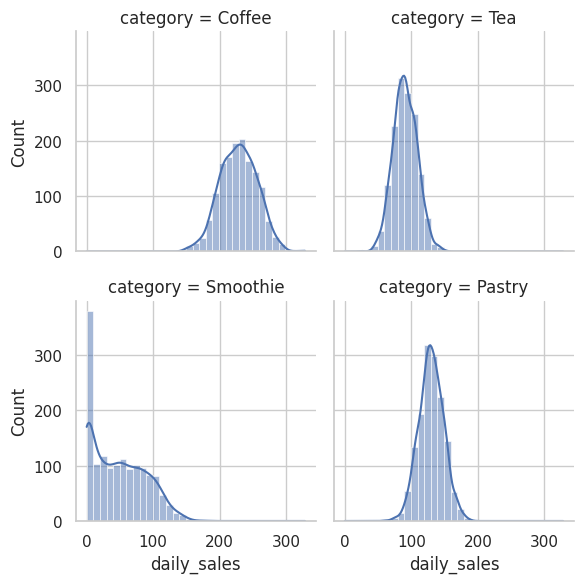

In [22]:
# rugplot: a tick per observation, usually paired with a kde
# ecdfplot: "what % of days sold less than X?"
# displot: the figure-level version of histplot/kdeplot/ecdfplot, with col= faceting

fig, ax = plt.subplots(figsize=(8, 3))
sns.kdeplot(data=df[df.category == "Coffee"], x="daily_sales", ax=ax)
sns.rugplot(data=df[df.category == "Coffee"], x="daily_sales", ax=ax)
plt.show()

sns.displot(data=df, x="daily_sales", col="category", kind="hist", kde=True, col_wrap=2, height=3)
plt.show()


### 🔧 Try it yourself

In [23]:
# 1. sns.scatterplot of num_customers (x) vs daily_sales (y), colored by category
# ...

# 2. sns.histplot of "rating", with hue="category"
# ...

# 3. sns.relplot faceted by city AGAIN, but kind="line" instead of the default scatter
#    hint: relplot(..., kind="line")
# ...


**✅ Checkpoint** — everyone can tell axes-level vs figure-level apart, and build both.

## Stage 6 — Seaborn: Categorical Plots (~20 min)

Comparing a number ACROSS categories — from "show every point" down to
"show one summary number."


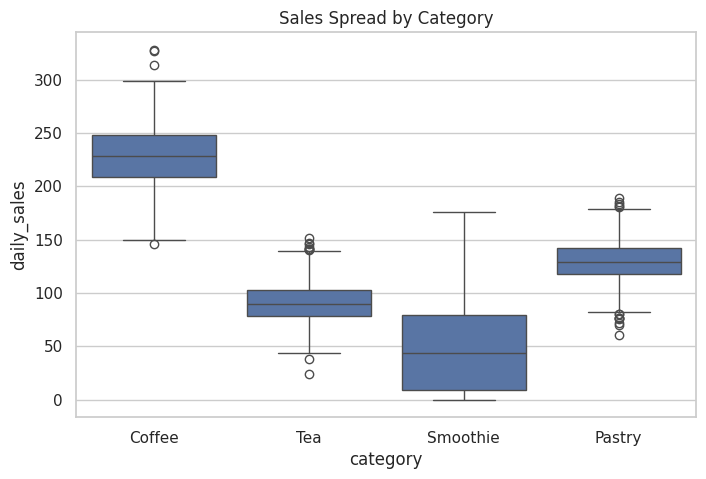

In [24]:
# BOXPLOT: median, quartiles, outliers
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="category", y="daily_sales", ax=ax)
ax.set_title("Sales Spread by Category")
plt.show()


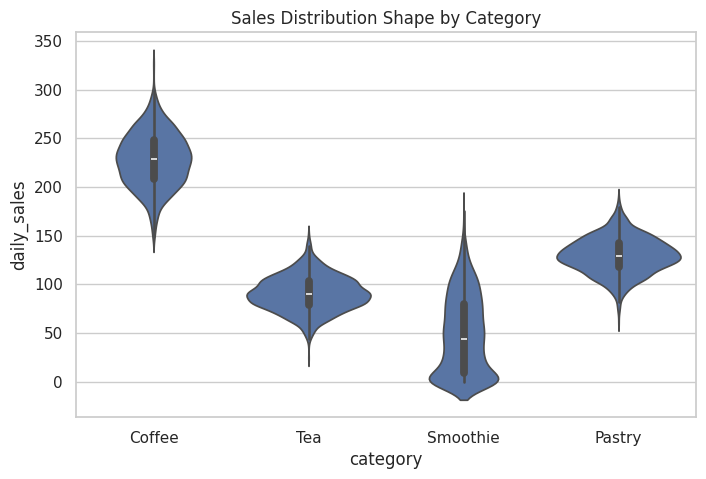

In [25]:
# VIOLINPLOT: same idea, but shows the full distribution shape
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df, x="category", y="daily_sales", ax=ax)
ax.set_title("Sales Distribution Shape by Category")
plt.show()


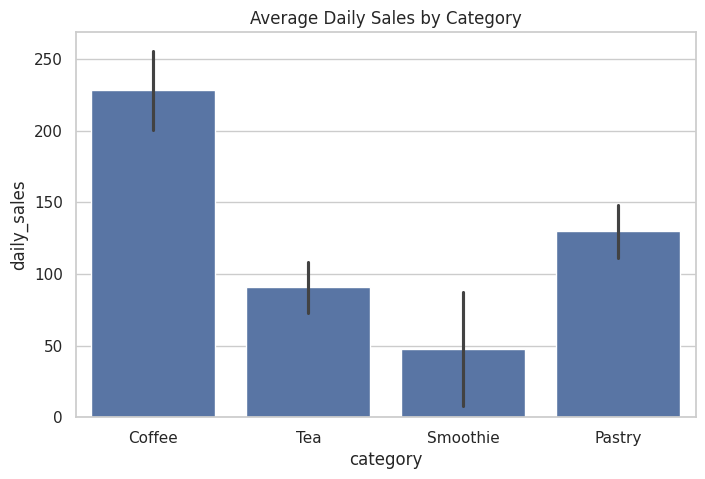

In [26]:
# BARPLOT: one summary number per category (mean, by default) + error bars
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x="category", y="daily_sales", estimator="mean", errorbar="sd", ax=ax)  # errorbar = +/- 1 std dev
ax.set_title("Average Daily Sales by Category")
plt.show()


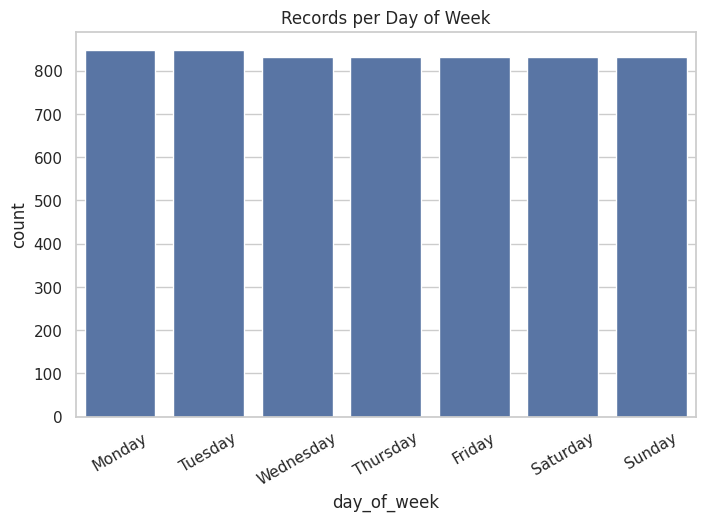

In [27]:
# COUNTPLOT: just counts rows per category - no y= needed
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="day_of_week", order=day_order, ax=ax)   # order= forces Mon->Sun
ax.set_title("Records per Day of Week")
ax.tick_params(axis="x", rotation=30)
plt.show()


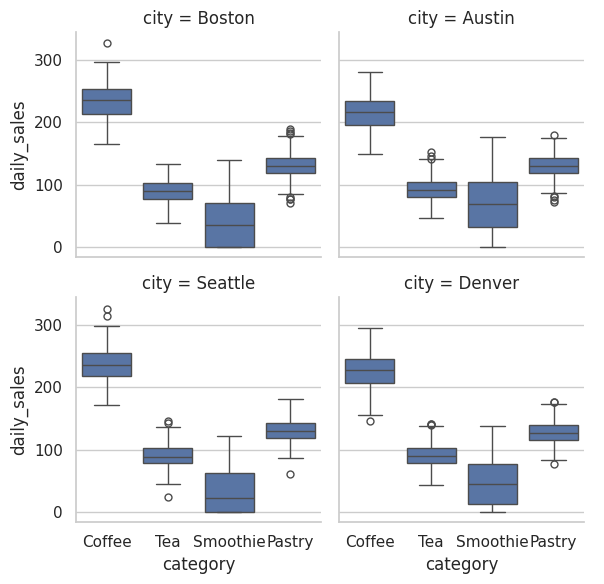

In [28]:
# CATPLOT: the figure-level version - swap kind= to change chart type everywhere at once
sns.catplot(data=df, x="category", y="daily_sales", col="city", kind="box", col_wrap=2, height=3)
plt.show()


### (optional) stripplot, swarmplot, boxenplot & pointplot

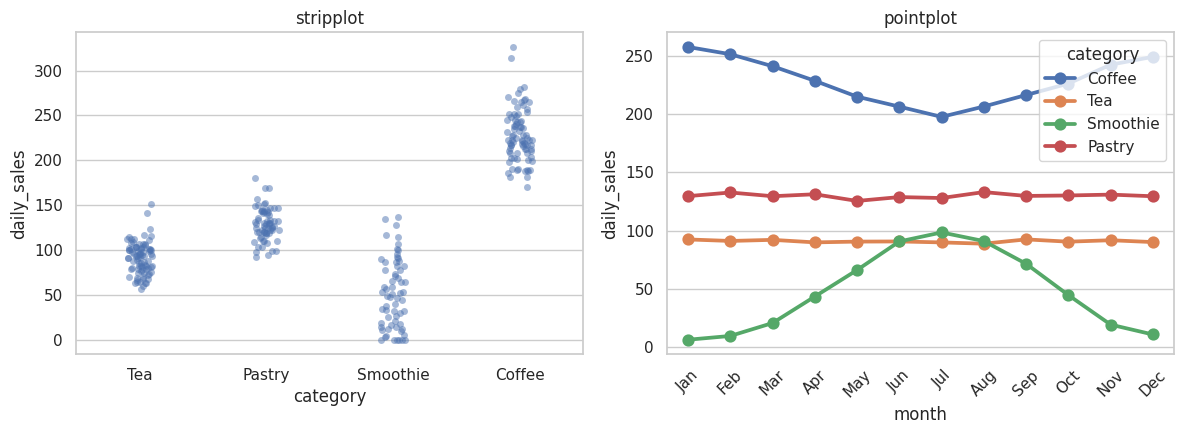

In [29]:
# stripplot/swarmplot: show EVERY point (subsample first - these get crowded fast)
# boxenplot: like boxplot but with more quantiles, good for big data
# pointplot: mean per category, connected by a line - good for spotting trends

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.stripplot(data=df.sample(300, random_state=3), x="category", y="daily_sales", alpha=0.5, ax=axes[0])
axes[0].set_title("stripplot")
sns.pointplot(data=df, x="month", y="daily_sales", hue="category", order=month_order, errorbar=None, ax=axes[1])
axes[1].set_title("pointplot")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


### 🔧 Try it yourself

In [30]:
# 1. sns.boxplot of avg_temp by city
# ...

# 2. sns.violinplot of rating by category
# ...

# 3. sns.catplot faceted by city, kind="violin" instead of "box"
# ...


**✅ Checkpoint** — everyone can pick the right categorical plot for a question.

## Stage 7 — Regression & Matrix Plots (~15 min)

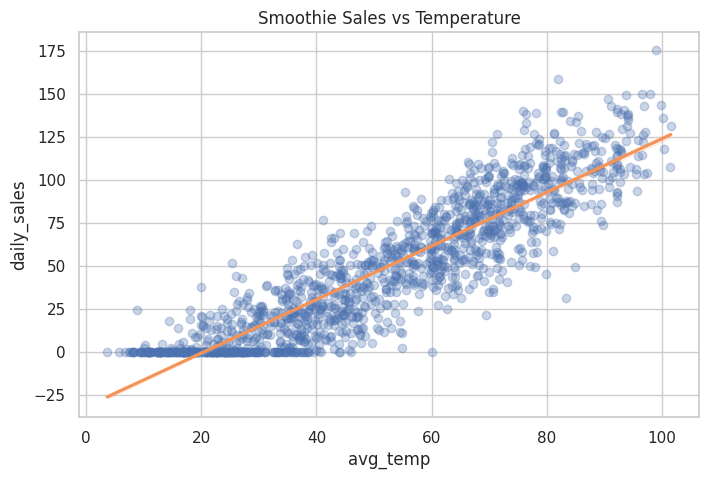

In [31]:
# regplot: scatter + fitted trend line + confidence band, in one call
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df[df.category == "Smoothie"], x="avg_temp", y="daily_sales",
            scatter_kws={"alpha": 0.3}, line_kws={"color": "#F79256"}, ax=ax)
ax.set_title("Smoothie Sales vs Temperature")
plt.show()


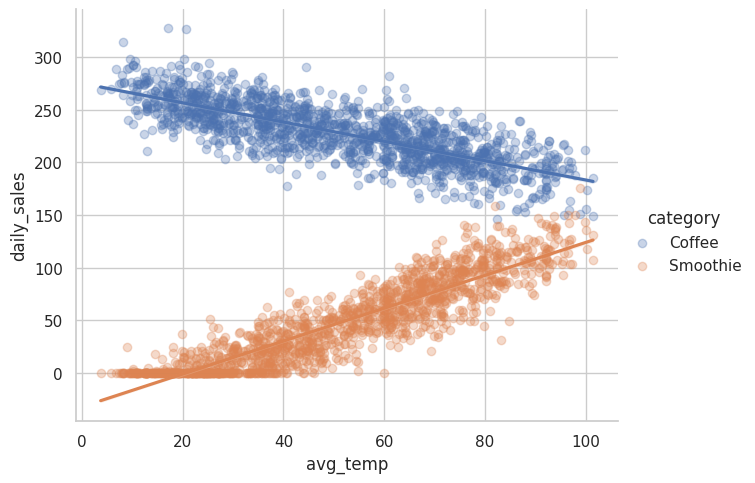

In [32]:
# lmplot: figure-level version - can fit a SEPARATE line per category
sns.lmplot(data=df[df.category.isin(["Coffee", "Smoothie"])], x="avg_temp", y="daily_sales",
           hue="category", height=5, aspect=1.3, scatter_kws={"alpha": 0.3})
# notice the two lines slope in opposite directions - that's the temperature effect we built into the data
plt.show()


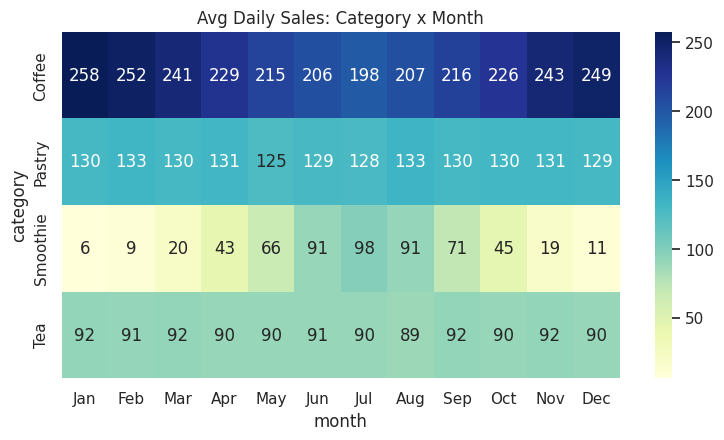

In [33]:
# HEATMAP: a value across two categories at once
pivot = df.pivot_table(index="category", columns="month", values="daily_sales", aggfunc="mean")[month_order]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax)   # annot=True prints the number in each cell
ax.set_title("Avg Daily Sales: Category x Month")
plt.show()


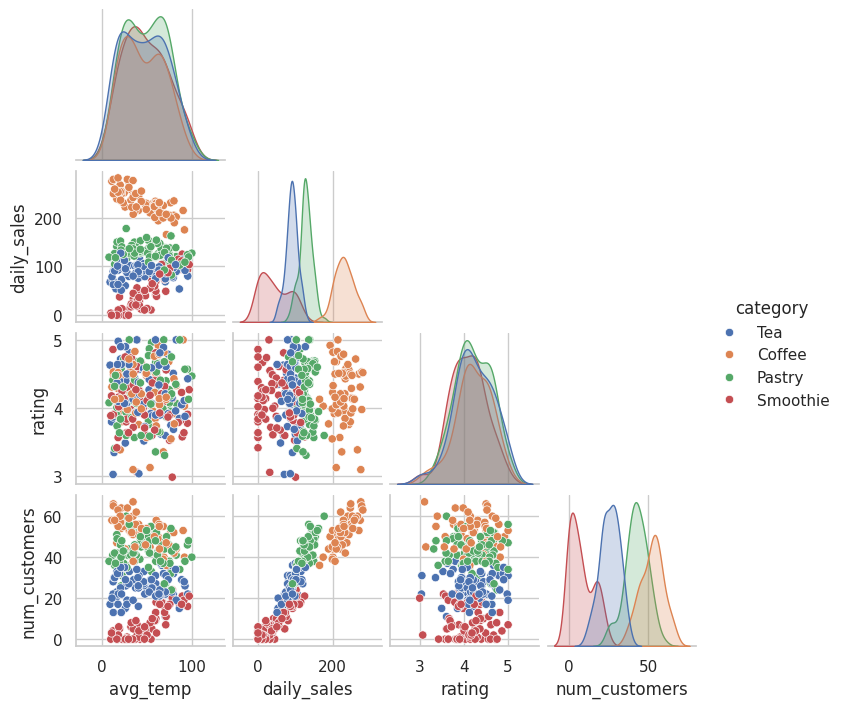

In [34]:
# PAIRPLOT: every numeric column plotted against every other, at once
small = df[["avg_temp", "daily_sales", "rating", "num_customers", "category"]].sample(300, random_state=2)
sns.pairplot(small, hue="category", corner=True, height=1.8)   # corner=True skips the redundant mirrored half
plt.show()


### (optional) jointplot & clustermap

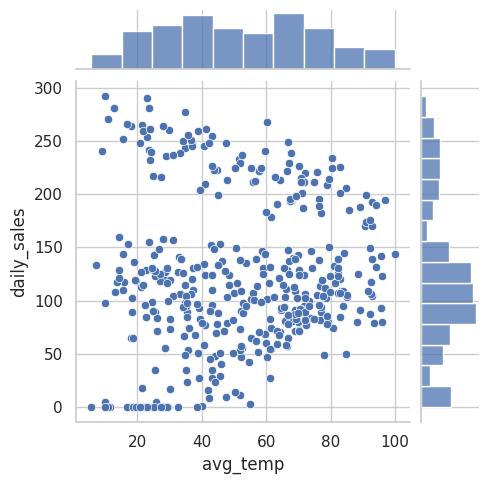

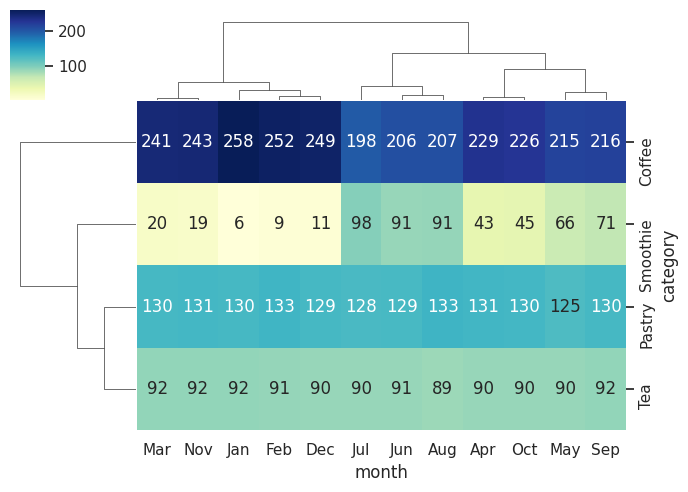

In [35]:
# jointplot: one scatter PLUS each variable's distribution on the side
sns.jointplot(data=df.sample(400, random_state=4), x="avg_temp", y="daily_sales", kind="scatter", height=5)
plt.show()

# clustermap: a heatmap that reorders rows/cols by similarity (needs scipy)
sns.clustermap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", figsize=(7, 5))
plt.show()


### 🔧 Try it yourself

In [36]:
# 1. sns.regplot of num_customers (x) vs daily_sales (y) for the Coffee category only
# ...

# 2. A correlation heatmap of just ["avg_temp","daily_sales","rating","num_customers"]
#    hint: df[[...]].corr(), then sns.heatmap(corr, annot=True)
# ...


**✅ Checkpoint** — everyone can fit and read a trend line, and build a heatmap.

## Stage 8 — Combining Both Libraries + Wrap-Up (~10 min)

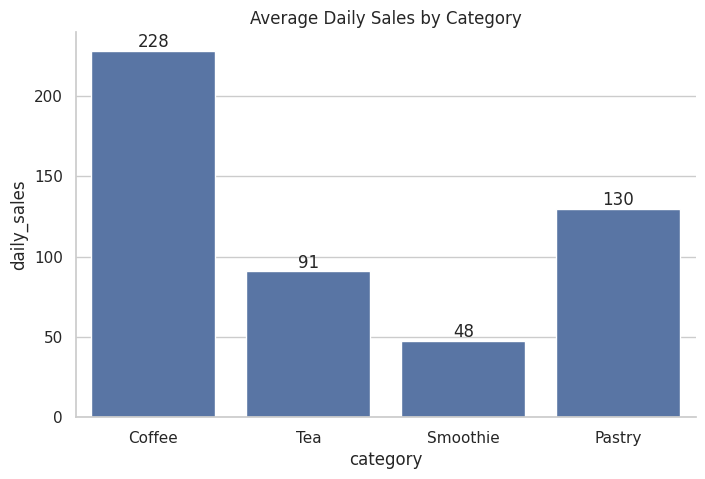

In [37]:
# Every seaborn call returns a matplotlib Axes - keep customizing with plain matplotlib
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=df, x="category", y="daily_sales", estimator="mean", errorbar=None, ax=ax)  # seaborn draws the bars

for container in ax.containers:              # matplotlib: loop over each group of bars
    ax.bar_label(container, fmt="%.0f")        # matplotlib: print the value above each bar

ax.set_title("Average Daily Sales by Category")   # matplotlib
sns.despine(ax=ax)                                  # seaborn: remove top/right border lines
plt.show()


## Cheat Sheet

| Goal | Matplotlib | Seaborn (axes-level) | Seaborn (figure-level) |
|---|---|---|---|
| Trend over time | `plt.plot` | `sns.lineplot` | `sns.relplot(kind="line")` |
| Relationship between 2 numbers | `plt.scatter` | `sns.scatterplot` | `sns.relplot(kind="scatter")` |
| Compare totals across categories | `plt.bar` | `sns.barplot` | `sns.catplot(kind="bar")` |
| Distribution of one variable | `plt.hist` | `sns.histplot` / `sns.kdeplot` | `sns.displot` |
| Spread across categories | — | `sns.boxplot` / `sns.violinplot` | `sns.catplot(kind="box")` |
| Trend line through a scatter | — | `sns.regplot` | `sns.lmplot` |
| Two categories at once | — | `sns.heatmap` | — |
| Every variable vs every other | — | — | `sns.pairplot` |

## Capstone Exercise

Using `df`:

1. Build a `sns.lineplot` of average `rating` by month, one line per `city`.
2. Build a `sns.boxplot` of `avg_temp` by `city`.
3. Build a `sns.catplot` faceted by `city`, `kind="violin"`.
4. Build a correlation heatmap using only weekend rows (`df[df.is_weekend]`).
5. Save one chart to disk with `fig.savefig(...)`.


In [38]:
# Capstone starter - fill in the ...

# 1.
# fig, ax = plt.subplots(figsize=(8, 5))
# sns.lineplot(data=..., x=..., y=..., hue=..., ax=ax)
# plt.show()

# 2.
# fig, ax = plt.subplots(figsize=(8, 5))
# sns.boxplot(data=..., x=..., y=..., ax=ax)
# plt.show()

# 3.
# sns.catplot(data=..., x=..., y=..., col=..., kind="violin")
# plt.show()

# 4.
# weekend_df = df[df.is_weekend]
# corr = weekend_df[[...]].corr()
# sns.heatmap(corr, annot=True)
# plt.show()

# 5.
# fig.savefig("my_chart.png", dpi=150, bbox_inches="tight")
